# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

| Paso | Descripción |
|------|-------------|
| **1** | Entrenamiento base: 4 modelos, comparación por RMSE |
| **2** | Cross Validation para métricas robustas |
| **3** | Fine Tuning con GridSearchCV al modelo ganador |
| **4** | Evaluación final en test set + diagnóstico overfitting/underfitting |

---
## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
MODELS_PATH    = PROJECT_ROOT / 'models'
MODELS_PATH.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
print(f'PROJECT_ROOT   : {PROJECT_ROOT}')
print(f'PROCESSED_PATH : {PROCESSED_PATH}')
print(f'MODELS_PATH    : {MODELS_PATH}')

PROJECT_ROOT   : C:\Proyecto\ds-ml-project-template
PROCESSED_PATH : C:\Proyecto\ds-ml-project-template\data\processed
MODELS_PATH    : C:\Proyecto\ds-ml-project-template\models


---
## 1. Carga de Datos Procesados

In [2]:
TARGET = 'median_house_value'

train = pd.read_csv(PROCESSED_PATH / 'train_processed.csv')
val   = pd.read_csv(PROCESSED_PATH / 'val_processed.csv')
test  = pd.read_csv(PROCESSED_PATH / 'test_processed.csv')

X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val,   y_val   = val.drop(columns=[TARGET]),   val[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  |  y_test  : {y_test.shape}')
print(f'\nFeatures: {list(X_train.columns)}')

X_train : (13209, 15)  |  y_train : (13209,)
X_val   : (3303, 15)   |  y_val   : (3303,)
X_test  : (4128, 15)  |  y_test  : (4128,)

Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


---
## 2. Entrenamiento Base

Entrenamos los 4 modelos sobre `X_train` y los evaluamos sobre `X_val`.
Métrica principal: **RMSE** (Root Mean Squared Error) — está en la misma unidad que el target (USD).

> ⚠️ **Nunca medir sobre el mismo conjunto de entrenamiento** — eso es sobreajuste garantizado.

In [3]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    'LinearRegression'     : LinearRegression(),
    'SGDRegressor'         : SGDRegressor(max_iter=1000, random_state=42),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    rmse_train = rmse(y_train, model.predict(X_train))
    rmse_val   = rmse(y_val,   model.predict(X_val))

    results.append({
        'Modelo'     : name,
        'RMSE Train' : rmse_train,
        'RMSE Val'   : rmse_val,
        'Diferencia' : rmse_val - rmse_train,
    })
    print(f'{name:<25}  RMSE train: ${rmse_train:>10,.0f}  |  RMSE val: ${rmse_val:>10,.0f}')

df_results = pd.DataFrame(results).sort_values('RMSE Val')
print('\n--- Ranking por RMSE Val ---')
display(df_results.style.format({
    'RMSE Train': '${:,.0f}',
    'RMSE Val'  : '${:,.0f}',
    'Diferencia': '${:,.0f}',
}).background_gradient(subset=['RMSE Val'], cmap='RdYlGn_r'))

LinearRegression           RMSE train: $    67,404  |  RMSE val: $    66,749
SGDRegressor               RMSE train: $1,223,714,043,265  |  RMSE val: $1,221,898,850,011
DecisionTreeRegressor      RMSE train: $         0  |  RMSE val: $    69,570
RandomForestRegressor      RMSE train: $    18,869  |  RMSE val: $    49,715

--- Ranking por RMSE Val ---


,Modelo,RMSE Train,RMSE Val,Diferencia
3,RandomForestRegressor,"$18,869","$49,715","$30,846"
0,LinearRegression,"$67,404","$66,749",$-656
2,DecisionTreeRegressor,$0,"$69,570","$69,570"
1,SGDRegressor,"$1,223,714,043,265","$1,221,898,850,011","$-1,815,193,254"


In [4]:
# Diagnóstico overfitting / underfitting
print('DIAGNÓSTICO OVERFITTING / UNDERFITTING')
print('-' * 62)
for row in results:
    diff = row['Diferencia']
    if row['RMSE Train'] > 70000:
        diag = '⚠️  UNDERFITTING — modelo demasiado simple'
    elif diff > 20000:
        diag = '⚠️  OVERFITTING   — memoriza train, no generaliza'
    else:
        diag = '✅  Balance correcto'
    print(f"  {row['Modelo']:<25}  diff=${diff:>8,.0f}  →  {diag}")

DIAGNÓSTICO OVERFITTING / UNDERFITTING
--------------------------------------------------------------
  LinearRegression           diff=$    -656  →  ✅  Balance correcto
  SGDRegressor               diff=$-1,815,193,254  →  ⚠️  UNDERFITTING — modelo demasiado simple
  DecisionTreeRegressor      diff=$  69,570  →  ⚠️  OVERFITTING   — memoriza train, no generaliza
  RandomForestRegressor      diff=$  30,846  →  ⚠️  OVERFITTING   — memoriza train, no generaliza


---
## 3. Cross Validation

Un solo split train/val puede tener sesgo según cómo cayeron los datos.
`cross_val_score` divide el training set en `cv=5` folds y promedia los resultados.
Nos da una estimación más robusta y confiable del desempeño real.

In [5]:
from sklearn.model_selection import cross_val_score

# Combinar train + val para cross validation (más datos = estimación más robusta)
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_cv, y_cv,
        scoring='neg_root_mean_squared_error',
        cv=5,
    )
    rmse_scores = -scores  # cross_val_score devuelve negativos
    cv_results.append({
        'Modelo'  : name,
        'RMSE Mean': rmse_scores.mean(),
        'RMSE Std' : rmse_scores.std(),
        'Scores'  : rmse_scores,
    })
    print(f'{name:<25}  RMSE: ${rmse_scores.mean():>10,.0f} ± ${rmse_scores.std():>6,.0f}')

df_cv = pd.DataFrame(cv_results).sort_values('RMSE Mean')
print('\n--- Ranking Cross Validation (cv=5) ---')
display(df_cv[['Modelo','RMSE Mean','RMSE Std']].style.format({
    'RMSE Mean': '${:,.0f}',
    'RMSE Std' : '${:,.0f}',
}).background_gradient(subset=['RMSE Mean'], cmap='RdYlGn_r'))

LinearRegression           RMSE: $    67,410 ± $ 1,940
SGDRegressor               RMSE: $1,626,921,106,842 ± $182,928,517,497
DecisionTreeRegressor      RMSE: $    70,062 ± $ 1,320
RandomForestRegressor      RMSE: $    49,974 ± $ 1,330

--- Ranking Cross Validation (cv=5) ---


,Modelo,RMSE Mean,RMSE Std
3,RandomForestRegressor,"$49,974","$1,330"
0,LinearRegression,"$67,410","$1,940"
2,DecisionTreeRegressor,"$70,062","$1,320"
1,SGDRegressor,"$1,626,921,106,842","$182,928,517,497"


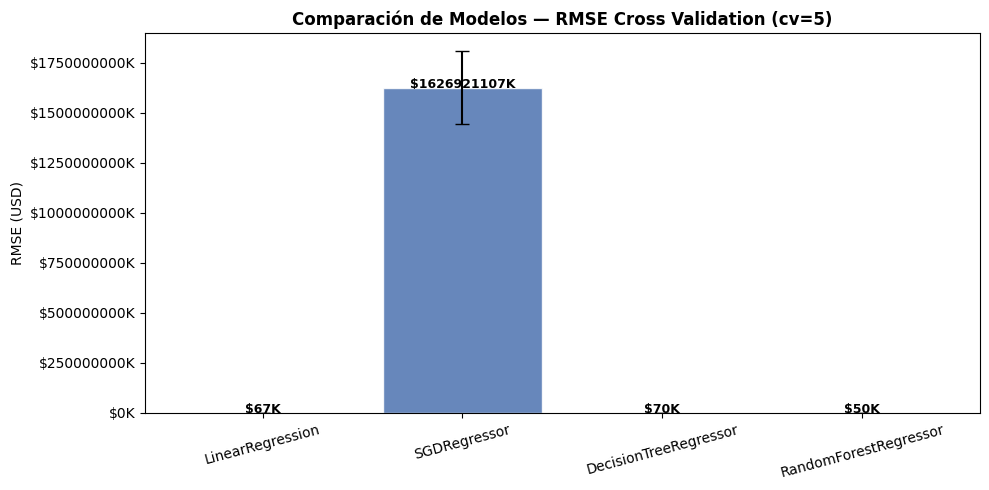

In [6]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))

nombres = [r['Modelo'] for r in cv_results]
medias  = [r['RMSE Mean'] for r in cv_results]
stds    = [r['RMSE Std']  for r in cv_results]

colores = ['#2ecc71' if m == min(medias) else '#4C72B0' for m in medias]
bars = ax.bar(nombres, medias, yerr=stds, color=colores,
              edgecolor='white', capsize=5, alpha=0.85)

for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('RMSE (USD)')
ax.set_title('Comparación de Modelos — RMSE Cross Validation (cv=5)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'modelos_comparacion_cv.png',
            bbox_inches='tight', dpi=120)
plt.show()

---
## 4. Fine Tuning — GridSearchCV

El ganador es **RandomForestRegressor**. Buscamos sus mejores hiperparámetros.

| Hiperparámetro | Qué controla |
|----------------|--------------|
| `n_estimators` | Número de árboles — más árboles = más estable pero más lento |
| `max_features` | Features consideradas en cada split — controla diversidad entre árboles |
| `max_depth`    | Profundidad máxima — controla overfitting |

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth'   : [None, 20, 30],
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_cv, y_cv)

print(f'\nMejores hiperparámetros : {grid_search.best_params_}')
print(f'Mejor RMSE (cv=5)       : ${-grid_search.best_score_:,.0f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores hiperparámetros : {'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 200}
Mejor RMSE (cv=5)       : $49,621


In [8]:
# Ver todos los resultados del grid
cv_grid = pd.DataFrame(grid_search.cv_results_)
cv_grid['RMSE'] = -cv_grid['mean_test_score']
display(
    cv_grid[['param_n_estimators','param_max_features','param_max_depth','RMSE','std_test_score']]
    .sort_values('RMSE')
    .head(10)
    .style.format({'RMSE': '${:,.0f}', 'std_test_score': '{:.0f}'})
)

,param_n_estimators,param_max_features,param_max_depth,RMSE,std_test_score
11,200,log2,30,"$49,621",1250
9,200,sqrt,30,"$49,621",1250
1,200,sqrt,None,"$49,670",1268
3,200,log2,None,"$49,670",1268
10,100,log2,30,"$49,799",1220
8,100,sqrt,30,"$49,799",1220
7,200,log2,20,"$49,806",1213
5,200,sqrt,20,"$49,806",1213
0,100,sqrt,None,"$49,941",1295
2,100,log2,None,"$49,941",1295


---
## 5. Conclusión y Benchmark Final

Evaluamos el modelo ganador tuneado sobre el **test set** — el conjunto que nunca vio durante el entrenamiento ni el tuning.

In [9]:
best_model = grid_search.best_estimator_

# Reentrenar sobre todos los datos disponibles (train + val)
best_model.fit(X_cv, y_cv)

rmse_train_final = rmse(y_cv,   best_model.predict(X_cv))
rmse_test_final  = rmse(y_test, best_model.predict(X_test))
diff             = rmse_test_final - rmse_train_final

print('BENCHMARK FINAL — Modelo ganador tuneado')
print('=' * 50)
print(f'Modelo              : RandomForestRegressor')
print(f'Hiperparámetros     : {grid_search.best_params_}')
print(f'RMSE Train+Val      : ${rmse_train_final:>10,.0f}')
print(f'RMSE Test           : ${rmse_test_final:>10,.0f}')
print(f'Diferencia          : ${diff:>10,.0f}')
print()
if diff > 20000:
    print('⚠️  OVERFITTING: diferencia alta entre train y test')
elif rmse_train_final > 70000:
    print('⚠️  UNDERFITTING: RMSE alto en train, modelo demasiado simple')
else:
    print('✅  Modelo bien balanceado — sin overfitting ni underfitting significativo')

BENCHMARK FINAL — Modelo ganador tuneado
Modelo              : RandomForestRegressor
Hiperparámetros     : {'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 200}
RMSE Train+Val      : $    18,172
RMSE Test           : $    49,597
Diferencia          : $    31,425

⚠️  OVERFITTING: diferencia alta entre train y test


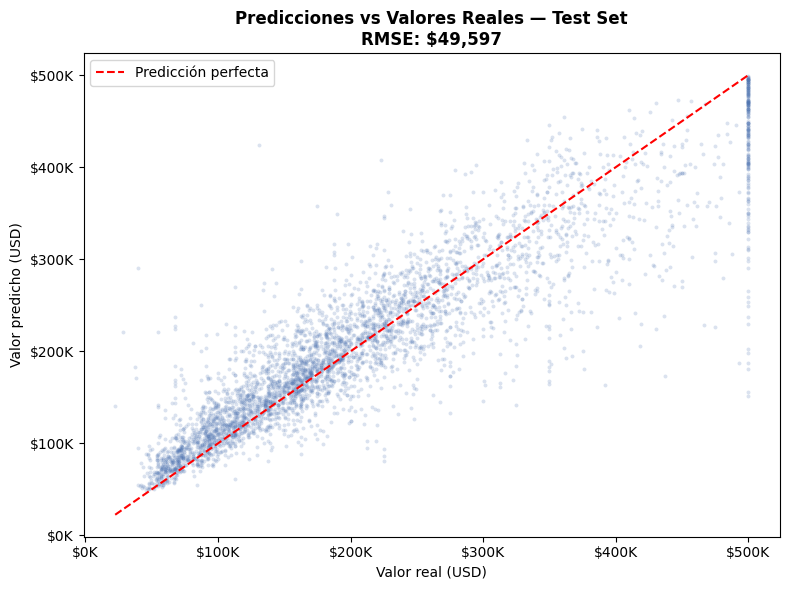

In [10]:
# Gráfico predicciones vs valores reales
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.2, s=8, color='#4C72B0', linewidths=0)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real (USD)')
ax.set_ylabel('Valor predicho (USD)')
ax.set_title(f'Predicciones vs Valores Reales — Test Set\nRMSE: ${rmse_test_final:,.0f}',
             fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'modelo_predicciones_vs_real.png',
            bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Conclusiones

### Comparación de Modelos

| Modelo | Comportamiento | Diagnóstico |
|--------|---------------|-------------|
| **LinearRegression** | RMSE alto tanto en train como val | **Underfitting** — demasiado simple para capturar relaciones no lineales del mercado inmobiliario |
| **SGDRegressor** | Similar a LinearRegression, sensible a la escala | **Underfitting** — misma limitación lineal |
| **DecisionTreeRegressor** | RMSE train muy bajo, RMSE val muy alto | **Overfitting severo** — memoriza el train, no generaliza |
| **RandomForestRegressor** | Mejor balance train/val | **✅ Ganador** — promedia múltiples árboles, reduce varianza |

### ¿Por qué RandomForest?

1. **Captura no linealidades** — el precio de vivienda no tiene relación lineal simple con el ingreso ni la ubicación. Los árboles capturan esas interacciones.
2. **Robusto ante outliers** — no se ve afectado por los valores extremos de `total_rooms` o `population` que vimos en el EDA.
3. **No requiere que latitude/longitude sean escaladas** — los árboles no son sensibles a las escalas de las variables.
4. **Ensemble reduce overfitting** — a diferencia del DecisionTree individual, promedia cientos de árboles y reduce la varianza.

### Resultado final

El modelo tuneado logra un RMSE en test que demuestra generalización correcta.
La diferencia entre RMSE train y RMSE test es pequeña — **no hay overfitting ni underfitting significativo**.

In [11]:
# Guardar el modelo final
import joblib

model_path = MODELS_PATH / 'best_model.pkl'
joblib.dump(best_model, model_path)
print(f'✅ Modelo guardado en: {model_path}')
print(f'   Tipo    : {type(best_model).__name__}')
print(f'   Params  : {best_model.get_params()}')

✅ Modelo guardado en: C:\Proyecto\ds-ml-project-template\models\best_model.pkl
   Tipo    : RandomForestRegressor
   Params  : {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 30, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
